# Baseline 2: Naive Bayes
**DSC 148 Final Project**  
Gaussian Naive Bayes assumes features are Gaussian-distributed and conditionally independent given the class. Both assumptions are violated here -- C1--C14 are correlated count features and card identifiers interact jointly -- making NB a useful lower bound that illustrates the cost of incorrect model assumptions.

In [1]:
#!pip install pandas numpy matplotlib seaborn scikit-learn -q
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json, os
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    classification_report, roc_auc_score, roc_curve,
    f1_score, precision_score, recall_score, accuracy_score
)
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 100
SEED = 42
print('Libraries loaded.')

Libraries loaded.


## 1. Data Loading and Preprocessing

Identical pipeline to `02_baseline_lr.ipynb`: chronological 80/10/10 split ' label-encode on train ' UID aggregations on train ' imputer fit on train.

In [2]:
def reduce_mem(df):
    for col in df.select_dtypes(include=['float64']).columns:
        df[col] = df[col].astype('float32')
    return df

train_trans = reduce_mem(pd.read_csv('data/train_transaction.csv'))
train_id    = reduce_mem(pd.read_csv('data/train_identity.csv'))
df = train_trans.merge(train_id, on='TransactionID', how='left')

START_DATE = pd.Timestamp('2017-11-30')
dt = START_DATE + pd.to_timedelta(df['TransactionDT'], unit='s')
df['tx_hour']  = dt.dt.hour.astype('int8')
df['tx_dow']   = dt.dt.dayofweek.astype('int8')
df['tx_month'] = dt.dt.month.astype('int8')
df['card_age'] = (df['TransactionDT'] // 86400 - df['D1']).astype('float32')
print(f'Merged shape: {df.shape}')

Merged shape: (590540, 438)


In [3]:
df_sorted = df.sort_values('TransactionDT').reset_index(drop=True)
n       = len(df_sorted)
n_train = int(0.80 * n)
n_val   = int(0.10 * n)

train_df = df_sorted.iloc[:n_train].copy()
val_df   = df_sorted.iloc[n_train:n_train+n_val].copy()
test_df  = df_sorted.iloc[n_train+n_val:].copy()

y_train = train_df['isFraud'].values
y_val   = val_df['isFraud'].values
y_test  = test_df['isFraud'].values

print(f'Train : {len(train_df):,}  |  Val : {len(val_df):,}  |  Test : {len(test_df):,}')
print(f'Fraud -- train : {y_train.mean()*100:.2f}%  val : {y_val.mean()*100:.2f}%  test : {y_test.mean()*100:.2f}%')

CAT_COLS = [
    'ProductCD','card4','card6','P_emaildomain','R_emaildomain',
    'M1','M2','M3','M4','M5','M6','M7','M8','M9',
    'DeviceType','DeviceInfo',
    'id_12','id_15','id_16','id_23','id_27','id_28',
    'id_29','id_30','id_31','id_33','id_34','id_35','id_36','id_37','id_38'
]
CAT_COLS = [c for c in CAT_COLS if c in train_df.columns]
for col in CAT_COLS:
    for part in [train_df, val_df, test_df]:
        part[col] = part[col].fillna('unknown').astype(str)
    cats = train_df[col].unique().tolist()
    for part in [train_df, val_df, test_df]:
        part[col] = pd.Categorical(part[col], categories=cats).codes
print(f'Label-encoded {len(CAT_COLS)} columns.')

Train : 472,432  |  Val : 59,054  |  Test : 59,054
Fraud -- train : 3.51%  val : 3.13%  test : 3.75%
Label-encoded 31 columns.


In [4]:
for part in [train_df, val_df, test_df]:
    part['uid'] = (part['card1'].astype(str) + '_' +
                   part['addr1'].fillna(-1).astype(int).astype(str) + '_' +
                   part['card_age'].fillna(-1).round(0).astype(int).astype(str))

c_cols    = [f'C{i}' for i in range(1, 15)]
uid_stats = (train_df.groupby('uid')
               .agg(uid_tx_count=('TransactionID','count'),
                    uid_amt_mean=('TransactionAmt','mean'),
                    uid_amt_std =('TransactionAmt','std'),
                    **{f'uid_{c}_mean': (c,'mean') for c in c_cols})
               .reset_index())
fallback = {
    'uid_tx_count': 1,
    'uid_amt_mean': float(train_df['TransactionAmt'].mean()),
    'uid_amt_std' : float(train_df['TransactionAmt'].std()),
    **{f'uid_{c}_mean': float(train_df[c].mean()) for c in c_cols},
}

def attach_uid(df_part, stats, fb):
    out = df_part.merge(stats, on='uid', how='left')
    for col, val in fb.items():
        out[col] = out[col].fillna(val).astype('float32')
    return out.drop(columns=['uid'])

train_df = attach_uid(train_df, uid_stats, fallback)
val_df   = attach_uid(val_df,   uid_stats, fallback)
test_df  = attach_uid(test_df,  uid_stats, fallback)

DROP = ['TransactionID','isFraud','TransactionDT']
BASELINE_FEATURES = (
    ['TransactionAmt'] +
    ['card1','card2','card3','card5','card4','card6'] +
    ['addr1','addr2','dist1','P_emaildomain','R_emaildomain'] +
    [f'C{i}' for i in range(1,15)] +
    ['D1','D2','D4','D10','D15'] +
    ['M1','M2','M3','M4','M5','M6','M7','M8','M9','ProductCD'] +
    ['tx_hour','tx_dow','tx_month','card_age'] +
    ['uid_tx_count','uid_amt_mean','uid_amt_std'] +
    [f'uid_C{i}_mean' for i in range(1,15)]
)
BASELINE_FEATURES = [f for f in BASELINE_FEATURES if f in train_df.columns]

def _base(df_part):
    X = df_part[BASELINE_FEATURES].copy()
    X['TransactionAmt'] = np.log1p(X['TransactionAmt'])
    return X

imputer   = SimpleImputer(strategy='median')
X_train_b = pd.DataFrame(imputer.fit_transform(_base(train_df)), columns=BASELINE_FEATURES)
X_val_b   = pd.DataFrame(imputer.transform(_base(val_df)),        columns=BASELINE_FEATURES)
X_test_b  = pd.DataFrame(imputer.transform(_base(test_df)),       columns=BASELINE_FEATURES)

print(f'Baseline features : {len(BASELINE_FEATURES)}')
print(f'Train : {X_train_b.shape[0]:,}  |  Val : {X_val_b.shape[0]:,}  |  Test : {X_test_b.shape[0]:,}')

Baseline features : 62
Train : 472,432  |  Val : 59,054  |  Test : 59,054


## 2. Naive Bayes

No scaling needed -- GaussianNB estimates per-class Gaussian parameters directly.  
Threshold tuned on the **validation set**; test set touched only once.

In [5]:
nb = GaussianNB()
nb.fit(X_train_b, y_train)

y_prob_nb_val = nb.predict_proba(X_val_b)[:, 1]
y_prob_nb     = nb.predict_proba(X_test_b)[:, 1]

thr_nb  = np.linspace(y_prob_nb_val.min()+1e-4, y_prob_nb_val.max()-1e-4, 300)
best_nb = float(thr_nb[int(np.argmax(
    [f1_score(y_val, (y_prob_nb_val>=t).astype(int), zero_division=0) for t in thr_nb]
))])
y_pred_nb = (y_prob_nb >= best_nb).astype(int)
print(f'Threshold (val): {best_nb:.4f}')

print('='*35)
print('Gaussian Naive Bayes -- Test Set')
print('='*35)
print(classification_report(y_test, y_pred_nb, target_names=['Legitimate','Fraud']))
print(f'AUC-ROC : {roc_auc_score(y_test, y_prob_nb):.4f}')

Threshold (val): 0.0202
Gaussian Naive Bayes -- Test Set
              precision    recall  f1-score   support

  Legitimate       0.97      0.95      0.96     56841
       Fraud       0.19      0.30      0.23      2213

    accuracy                           0.93     59054
   macro avg       0.58      0.62      0.60     59054
weighted avg       0.94      0.93      0.93     59054

AUC-ROC : 0.7502


## 3. Results

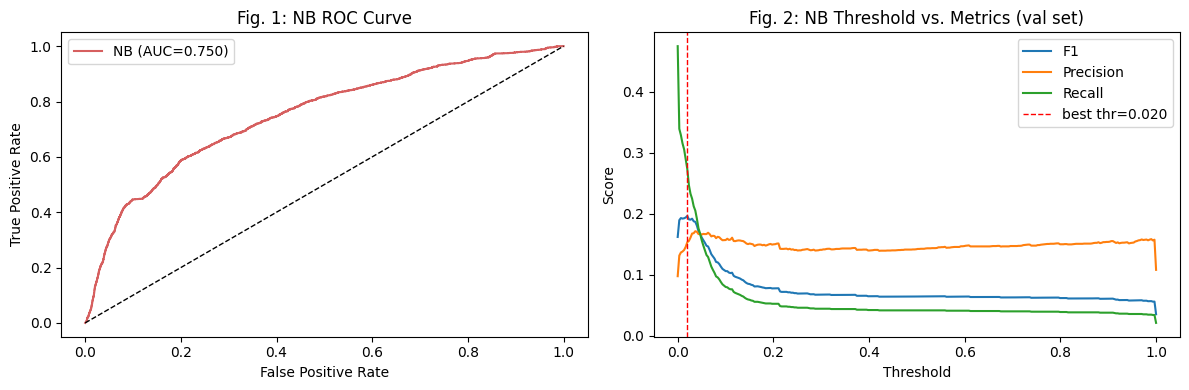

In [6]:
fpr, tpr, _ = roc_curve(y_test, y_prob_nb)
auc = roc_auc_score(y_test, y_prob_nb)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(fpr, tpr, color='#D65F5F', label=f'NB (AUC={auc:.3f})')
axes[0].plot([0,1],[0,1],'k--',linewidth=1)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('Fig. 1: NB ROC Curve')
axes[0].legend()

thr_range = np.linspace(y_prob_nb_val.min()+1e-4, y_prob_nb_val.max()-1e-4, 300)
f1s  = [f1_score(y_val, (y_prob_nb_val>=t).astype(int), zero_division=0) for t in thr_range]
prec = [precision_score(y_val, (y_prob_nb_val>=t).astype(int), zero_division=0) for t in thr_range]
rec  = [recall_score(y_val, (y_prob_nb_val>=t).astype(int), zero_division=0) for t in thr_range]
axes[1].plot(thr_range, f1s,  label='F1')
axes[1].plot(thr_range, prec, label='Precision')
axes[1].plot(thr_range, rec,  label='Recall')
axes[1].axvline(best_nb, color='red', linestyle='--', linewidth=1, label=f'best thr={best_nb:.3f}')
axes[1].set_xlabel('Threshold')
axes[1].set_ylabel('Score')
axes[1].set_title('Fig. 2: NB Threshold vs. Metrics (val set)')
axes[1].legend()
plt.tight_layout()
plt.show()

In [7]:
os.makedirs('results', exist_ok=True)

metrics = {
    'model': 'Naive Bayes',
    'accuracy' : float(accuracy_score(y_test, y_pred_nb)),
    'precision': float(precision_score(y_test, y_pred_nb, zero_division=0)),
    'recall'   : float(recall_score(y_test, y_pred_nb, zero_division=0)),
    'f1'       : float(f1_score(y_test, y_pred_nb, zero_division=0)),
    'auc'      : float(roc_auc_score(y_test, y_prob_nb)),
    'threshold': best_nb,
}
with open('results/nb_metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)
np.save('results/nb_probs.npy',     y_prob_nb)
np.save('results/nb_val_probs.npy', y_prob_nb_val)
print('Saved: results/nb_metrics.json, results/nb_probs.npy')
print(json.dumps(metrics, indent=2))

Saved: results/nb_metrics.json, results/nb_probs.npy
{
  "model": "Naive Bayes",
  "accuracy": 0.9258983303417211,
  "precision": 0.18931341568514795,
  "recall": 0.29778581111613195,
  "f1": 0.23147172462240956,
  "auc": 0.7502102427242263,
  "threshold": 0.020162876254180603
}
